In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader,Dataset
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    MeanStdBVPGaussianPath, DeterministicBVPPath, flow_matching_loss,
    FixedCenterThreeBodyPotential,ConfiguredPotential,
    to_numpy, as_particles as _as_particles, make_hamiltonian_node, make_mean_std_bvp_path,
    solve_bvp_paths, train_on_cached_path_pairs, train_on_ot_pairs as _train_on_ot_pairs,
    simulate_model_trajectory, cached_mean_trajectory, trajectory_hamiltonian,plot_trajectories_with_potential
)
from torchcfm.optimal_transport import OTPlanSampler,wasserstein
from torchcfm.models.models_v2 import MLP,FourierTimeResidualMLP
from torchcfm.utils import torch_wrapper

from ema_pytorch import EMA

if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:2')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

import copy

from torch.distributions import MultivariateNormal



def to_numpy(x):
    return x.detach().cpu().numpy()


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader,Dataset
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    MeanStdBVPGaussianPath, DeterministicBVPPath, flow_matching_loss,
    FixedCenterThreeBodyPotential,ConfiguredPotential,
    to_numpy, as_particles as _as_particles, make_hamiltonian_node, make_mean_std_bvp_path,
    solve_bvp_paths, train_on_cached_path_pairs, train_on_ot_pairs as _train_on_ot_pairs,
    simulate_model_trajectory, cached_mean_trajectory, trajectory_hamiltonian,plot_trajectories_with_potential
)
from torchcfm.optimal_transport import OTPlanSampler,wasserstein
from torchcfm.models.models_v2 import MLP,FourierTimeResidualMLP
from torchcfm.utils import torch_wrapper

from ema_pytorch import EMA

if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:3')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

import copy

from torch.distributions import MultivariateNormal



def to_numpy(x):
    return x.detach().cpu().numpy()


In [3]:
torch.manual_seed(0)
np.random.seed(0)

# Problem size and training controls.
dim              = 2 
batch_size = 2**6
n_dataset = 2**8
warmup_dataset = 5*n_dataset
n_epochs = 20
n_iters = 256
n_warmup_iters = 5000
batch_size_warmup = 1024
lr = 5e-4
bvp_sigma = 1e-2
quadrature_order = 4
n_steps = 50
tol = 1e-2
eval_batch = 2500
diagnostic_batch = eval_batch
block_size = 2
solve_t_span = torch.linspace(0, 1, n_steps + 1, device=device)



source_mean      = torch.tensor([-11.0, -1.0], device=device)
target_mean      = torch.tensor([11.0, 1.0], device=device)
gaussian_std     = torch.tensor(0.5, device=device)
solve_t_span     = torch.linspace(0, 1, n_steps + 1, device=device)

eval_batch       = 5000
print(f'device: {device}')


device: cuda


In [4]:
source_dist = MultivariateNormal(source_mean, gaussian_std**2 * torch.eye(dim, device=device))
target_dist = MultivariateNormal(target_mean, gaussian_std**2 * torch.eye(dim, device=device))

class TotalDataset(Dataset):
        
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return self.samples.shape[0]
    def __getitem__(self,idx):
        return self.samples[idx]
    
source_data = source_dist.sample((n_dataset,))
target_data = target_dist.sample((n_dataset,))

source_loader = DataLoader(TotalDataset(source_data),batch_size = batch_size, shuffle = True, drop_last = True)
target_loader = DataLoader(TotalDataset(target_data),batch_size = batch_size, shuffle = True, drop_last = True)

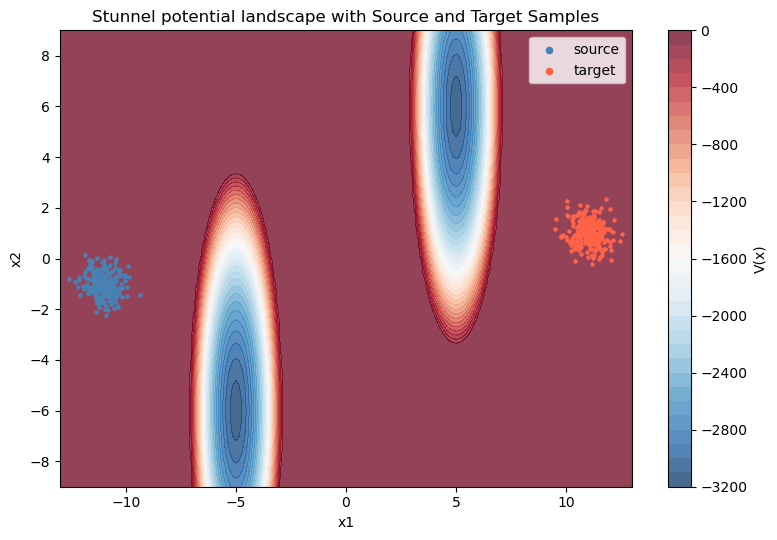

In [5]:


def sample_source(n):
    return source_dist.sample((n,)).to(device)


def sample_target(n):
    return target_dist.sample((n,)).to(device)


cfg_potential = {'linear': ('stunnel', -35), 'interaction': None, 'internal': None} #("rational_quadratic", -0.0)
potential = ConfiguredPotential(cfg_potential)
stunnel_centers = torch.tensor([[5.0, 6.0], [-5.0, -6.0]], device=device)

# Visualize potential landscape with source and target samples.
x_grid = np.linspace(-13, 13, 180)
y_grid = np.linspace(-9, 9, 140)
X, Y = np.meshgrid(x_grid, y_grid)
xy = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32, device=device)

with torch.no_grad():
    Z = to_numpy(potential.energy(xy)).reshape(Y.shape)

x0_vis = to_numpy(source_data)
x1_vis = to_numpy(target_data)


plt.figure(figsize=(8, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.75)
plt.colorbar(label='V(x)')
plt.scatter(x0_vis[:, 0], x0_vis[:, 1], s=5, c='steelblue', label='source')
plt.scatter(x1_vis[:, 0], x1_vis[:, 1], s=5, c='tomato', label='target')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title(f'{cfg_potential["linear"][0].capitalize()} potential landscape with Source and Target Samples')
plt.tight_layout()
plt.show()


In [6]:



ot_sampler = OTPlanSampler(method='exact')


def make_node(model):
    return make_hamiltonian_node(model)


def make_path(mu_guess=None, mu_dot_guess=None):
    if bvp_sigma == 0:
        return DeterministicBVPPath(
            potential,
            n_steps=n_steps,
            tol=tol,
            gamma_guess=mu_guess,
            gamma_prime_guess=mu_dot_guess,
        )
    if bvp_sigma > 0:
        return make_mean_std_bvp_path(
            potential,
            sigma=bvp_sigma,
            n_steps=n_steps,
            tol=tol,
            quadrature_order=quadrature_order,
            mu_guess=mu_guess,
            mu_dot_guess=mu_dot_guess,
            use_monte_carlo=False,
            monte_carlo_samples=5,
        )
    raise ValueError("bvp_sigma must be non-negative.")


def solve_paths(x0, x1, label="path", mu_guess=None, mu_dot_guess=None):
    def make_path_with_guesses():
        return make_path(mu_guess=mu_guess, mu_dot_guess=mu_dot_guess)

    return solve_bvp_paths(make_path_with_guesses, x0, x1, label=label, description="fixed-center three-body BVPs")


def trajectory_velocity_guesses(model, traj, t_span, x0, x1, reverse=True):
    if traj.ndim != 3:
        raise ValueError(f"traj must have shape (time, batch, dim); got {tuple(traj.shape)}.")
    if traj.shape[0] != t_span.numel():
        raise ValueError(f"traj has {traj.shape[0]} time steps, but t_span has {t_span.numel()}.")
    if traj.shape[0] != n_steps + 1:
        raise ValueError(f"traj must have n_steps + 1 = {n_steps + 1} time steps; got {traj.shape[0]}.")

    batch, guess_dim = traj.shape[1], traj.shape[2]
    x0_flat = x0.detach().reshape(x0.shape[0], -1)
    x1_flat = x1.detach().reshape(x1.shape[0], -1)
    if x0_flat.shape != (batch, guess_dim) or x1_flat.shape != (batch, guess_dim):
        raise ValueError(
            f"Endpoint shapes must flatten to {(batch, guess_dim)}; "
            f"got {tuple(x0_flat.shape)} and {tuple(x1_flat.shape)}."
        )

    was_training = model.training
    model.eval()
    with torch.no_grad():
        t_values = t_span.to(device=traj.device, dtype=traj.dtype).reshape(-1)
        velocities = []
        for k, t_value in enumerate(t_values):
            t_col = t_value.reshape(1, 1).expand(batch, 1)
            velocities.append(model(torch.cat([traj[k], t_col], dim=-1)))
        mu_dot = torch.stack(velocities, dim=0)
    if was_training:
        model.train()

    mu = traj.detach()
    if reverse:
        mu = torch.flip(mu, dims=(0,))
        mu_dot = -torch.flip(mu_dot, dims=(0,))

    mu_guess = mu.permute(1, 0, 2).contiguous().clone()
    mu_dot_guess = mu_dot.permute(1, 0, 2).contiguous().detach().clone()
    x0_flat = x0_flat.to(device=mu_guess.device, dtype=mu_guess.dtype)
    x1_flat = x1_flat.to(device=mu_guess.device, dtype=mu_guess.dtype)
    mu_guess[:, 0, :] = x0_flat
    mu_guess[:, -1, :] = x1_flat

    assert mu_guess.shape == mu_dot_guess.shape == (batch, n_steps + 1, guess_dim)
    assert torch.allclose(mu_guess[:, 0, :], x0_flat)
    assert torch.allclose(mu_guess[:, -1, :], x1_flat)
    return to_numpy(mu_guess), to_numpy(mu_dot_guess)


def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, ema=None, log_every=200):
    return train_on_cached_path_pairs(
        model, optimizer, path, x0, x1, n_steps_train, label, ema=ema,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
        no_pairs_message="no successful BVP pairs to train on",
    )


def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, log_every=500):
    return _train_on_ot_pairs(
        model, optimizer, x0, x1, n_steps_train, label,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
    )

In [7]:
ema_beta = 0.995
ema_update_after_step = 0
ema_update_every = 1
ema_freeze_batches = 0
ema_diag_every = ema_update_every


def mean_param_delta(model, ema_model):
    deltas = []
    with torch.no_grad():
        for param, ema_param in zip(model.parameters(), ema_model.parameters()):
            deltas.append((param - ema_param).abs().mean())
    if not deltas:
        return 0.0
    return torch.stack(deltas).mean().item()


def print_ema_diagnostic(context, generation_model=None):
    fwd_step = int(fwd_ema.step.item()) if fwd_ema is not None else -1
    bwd_step = int(bwd_ema.step.item()) if bwd_ema is not None else -1
    fwd_delta = mean_param_delta(fwd_model, fwd_ema.ema_model) if fwd_ema is not None else float('nan')
    bwd_delta = mean_param_delta(bwd_model, bwd_ema.ema_model) if bwd_ema is not None else float('nan')
    generation = f', generation={generation_model}' if generation_model is not None else ''
    print(
        f'{context}: fwd_ema_step={fwd_step}, bwd_ema_step={bwd_step}, '
        f'fwd_delta={fwd_delta:.3e}, bwd_delta={bwd_delta:.3e}{generation}'
    )






=== Alternating epoch 1 / 20 ===
epoch 0 batch 0 fwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 0 batch 0 fwd step     0: loss = 249.36554
epoch 0 batch 0 fwd step   200: loss = 48.09632
epoch 0 batch 0 fwd step   255: loss = 32.57892
epoch 0 batch 1 fwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 0 batch 1 fwd step     0: loss = 25.87986
epoch 0 batch 1 fwd step   200: loss = 0.13925
epoch 0 batch 1 fwd step   255: loss = 0.16595
epoch 0 batch 2 fwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 0 batch 2 fwd step     0: loss = 0.11521
epoch 0 batch 2 fwd step   200: loss = 0.07509
epoch 0 batch 2 fwd step   255: loss = 0.07586
epoch 0 batch 3 fwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 0 batch 3 fwd step     0: loss = 0.09792
epoch 0 batch 3 fwd step   200: loss = 0.06373
epoch 0 batch 3 fwd step   2

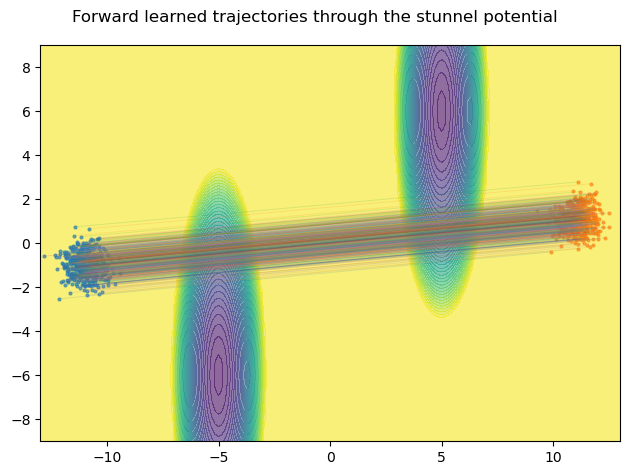


=== Alternating epoch 2 / 20 ===
epoch 1 batch 0 bwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 1 batch 0 bwd step     0: loss = 246.48488
epoch 1 batch 0 bwd step   200: loss = 34.32471
epoch 1 batch 0 bwd step   255: loss = 28.58371
epoch 1 batch 1 bwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 1 batch 1 bwd step     0: loss = 26.44941
epoch 1 batch 1 bwd step   200: loss = 0.11364
epoch 1 batch 1 bwd step   255: loss = 0.16630
epoch 1 batch 2 bwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 1 batch 2 bwd step     0: loss = 0.18556
epoch 1 batch 2 bwd step   200: loss = 0.11877
epoch 1 batch 2 bwd step   255: loss = 0.10046
epoch 1 batch 3 bwd: linear OT zero-potential path; kept 64 / 64 pairs; states: torch.Size([64, 51, 4])
epoch 1 batch 3 bwd step     0: loss = 0.15819
epoch 1 batch 3 bwd step   200: loss = 0.07427
epoch 1 batch 3 bwd step   2

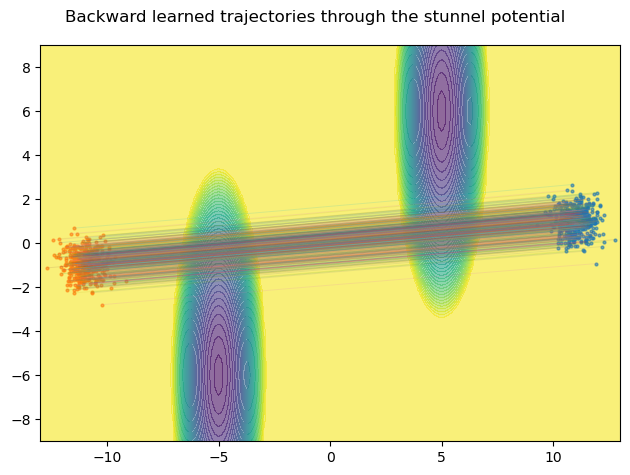


=== Alternating epoch 3 / 20 ===
Solving 64 epoch 2 batch 0 fwd fixed-center three-body BVPs...
epoch 2 batch 0 fwd: kept 25 / 64 BVPs; failed 39; states: torch.Size([25, 51, 6])
epoch 2 batch 0 fwd: first failures: [(0, 'The maximum number of mesh nodes is exceeded.'), (1, 'The maximum number of mesh nodes is exceeded.'), (4, 'The maximum number of mesh nodes is exceeded.'), (6, 'The maximum number of mesh nodes is exceeded.'), (7, 'The maximum number of mesh nodes is exceeded.')]
epoch 2 batch 0 fwd step     0: loss = 106.19534
epoch 2 batch 0 fwd step   200: loss = 2.60748
epoch 2 batch 0 fwd step   255: loss = 2.47294
Solving 64 epoch 2 batch 1 fwd fixed-center three-body BVPs...
epoch 2 batch 1 fwd: kept 27 / 64 BVPs; failed 37; states: torch.Size([27, 51, 6])
epoch 2 batch 1 fwd: first failures: [(0, 'The maximum number of mesh nodes is exceeded.'), (2, 'The maximum number of mesh nodes is exceeded.'), (3, 'The maximum number of mesh nodes is exceeded.'), (5, 'The maximum number

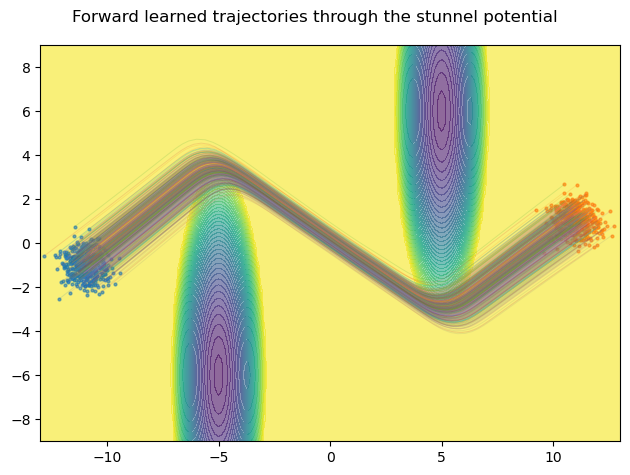


=== Alternating epoch 4 / 20 ===
Solving 64 epoch 3 batch 0 bwd fixed-center three-body BVPs...
epoch 3 batch 0 bwd: kept 62 / 64 BVPs; failed 2; states: torch.Size([62, 51, 6])
epoch 3 batch 0 bwd: first failures: [(17, 'The maximum number of mesh nodes is exceeded.'), (53, 'The maximum number of mesh nodes is exceeded.')]
epoch 3 batch 0 bwd step     0: loss = 88.55380
epoch 3 batch 0 bwd step   200: loss = 2.28953
epoch 3 batch 0 bwd step   255: loss = 2.77161
Solving 64 epoch 3 batch 1 bwd fixed-center three-body BVPs...
epoch 3 batch 1 bwd: kept 57 / 64 BVPs; failed 7; states: torch.Size([57, 51, 6])
epoch 3 batch 1 bwd: first failures: [(8, 'The maximum number of mesh nodes is exceeded.'), (32, 'The maximum number of mesh nodes is exceeded.'), (33, 'The maximum number of mesh nodes is exceeded.'), (34, 'The maximum number of mesh nodes is exceeded.'), (35, 'The maximum number of mesh nodes is exceeded.')]
epoch 3 batch 1 bwd step     0: loss = 1.29853
epoch 3 batch 1 bwd step   

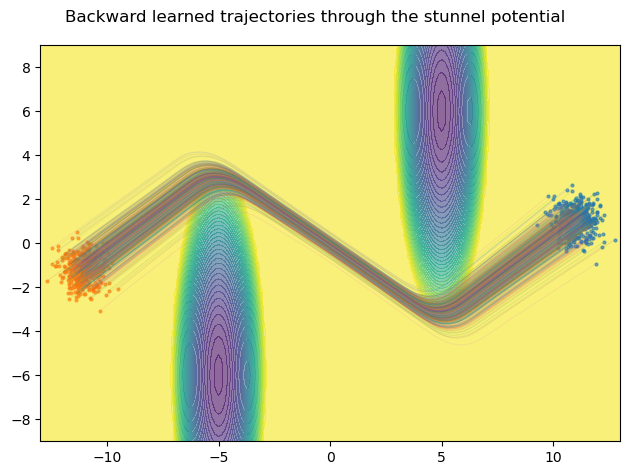


=== Alternating epoch 5 / 20 ===
Solving 64 epoch 4 batch 0 fwd fixed-center three-body BVPs...
epoch 4 batch 0 fwd: kept 57 / 64 BVPs; failed 7; states: torch.Size([57, 51, 6])
epoch 4 batch 0 fwd: first failures: [(7, 'The maximum number of mesh nodes is exceeded.'), (8, 'The maximum number of mesh nodes is exceeded.'), (17, 'The maximum number of mesh nodes is exceeded.'), (20, 'The maximum number of mesh nodes is exceeded.'), (22, 'The maximum number of mesh nodes is exceeded.')]
epoch 4 batch 0 fwd step     0: loss = 1.92141
epoch 4 batch 0 fwd step   200: loss = 1.87239
epoch 4 batch 0 fwd step   255: loss = 0.67396
Solving 64 epoch 4 batch 1 fwd fixed-center three-body BVPs...
epoch 4 batch 1 fwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 4 batch 1 fwd: first failures: [(20, 'The maximum number of mesh nodes is exceeded.')]
epoch 4 batch 1 fwd step     0: loss = 1.26624
epoch 4 batch 1 fwd step   200: loss = 0.52456
epoch 4 batch 1 fwd step   255: loss 

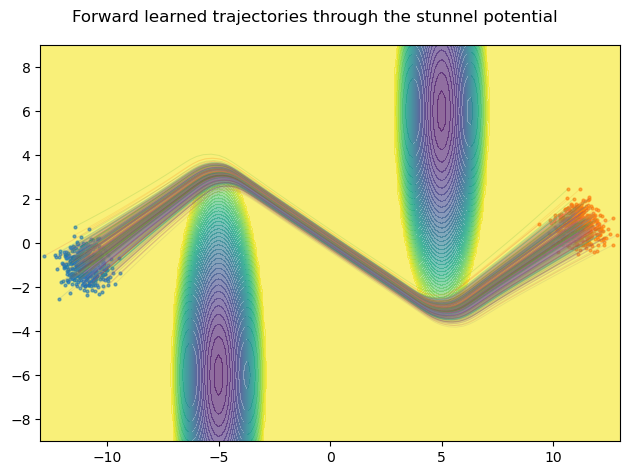


=== Alternating epoch 6 / 20 ===
Solving 64 epoch 5 batch 0 bwd fixed-center three-body BVPs...
epoch 5 batch 0 bwd: kept 55 / 64 BVPs; failed 9; states: torch.Size([55, 51, 6])
epoch 5 batch 0 bwd: first failures: [(12, 'The maximum number of mesh nodes is exceeded.'), (17, 'The maximum number of mesh nodes is exceeded.'), (39, 'The maximum number of mesh nodes is exceeded.'), (46, 'The maximum number of mesh nodes is exceeded.'), (52, 'The maximum number of mesh nodes is exceeded.')]
epoch 5 batch 0 bwd step     0: loss = 1.02064
epoch 5 batch 0 bwd step   200: loss = 0.59241
epoch 5 batch 0 bwd step   255: loss = 0.63914
Solving 64 epoch 5 batch 1 bwd fixed-center three-body BVPs...
epoch 5 batch 1 bwd: kept 61 / 64 BVPs; failed 3; states: torch.Size([61, 51, 6])
epoch 5 batch 1 bwd: first failures: [(18, 'The maximum number of mesh nodes is exceeded.'), (33, 'The maximum number of mesh nodes is exceeded.'), (44, 'The maximum number of mesh nodes is exceeded.')]
epoch 5 batch 1 bwd

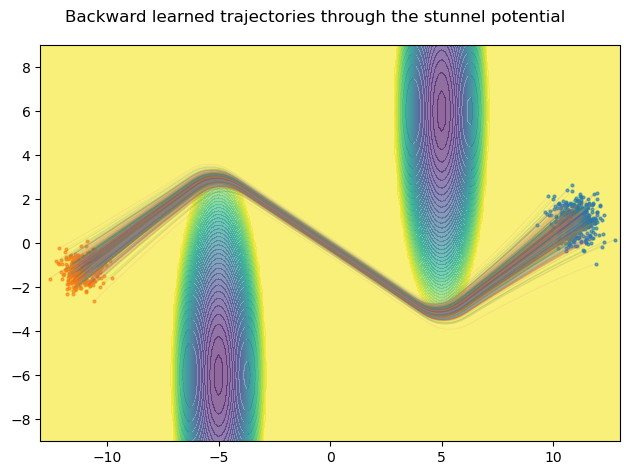


=== Alternating epoch 7 / 20 ===
Solving 64 epoch 6 batch 0 fwd fixed-center three-body BVPs...
epoch 6 batch 0 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 6 batch 0 fwd step     0: loss = 0.56676
epoch 6 batch 0 fwd step   200: loss = 0.33092
epoch 6 batch 0 fwd step   255: loss = 0.24069
Solving 64 epoch 6 batch 1 fwd fixed-center three-body BVPs...
epoch 6 batch 1 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 6 batch 1 fwd step     0: loss = 0.17460
epoch 6 batch 1 fwd step   200: loss = 0.51360
epoch 6 batch 1 fwd step   255: loss = 0.40760
Solving 64 epoch 6 batch 2 fwd fixed-center three-body BVPs...
epoch 6 batch 2 fwd: kept 62 / 64 BVPs; failed 2; states: torch.Size([62, 51, 6])
epoch 6 batch 2 fwd: first failures: [(12, 'The maximum number of mesh nodes is exceeded.'), (13, 'The maximum number of mesh nodes is exceeded.')]
epoch 6 batch 2 fwd step     0: loss = 0.32635
epoch 6 batch 2 fwd step   200: loss = 0.27623
epoch 6

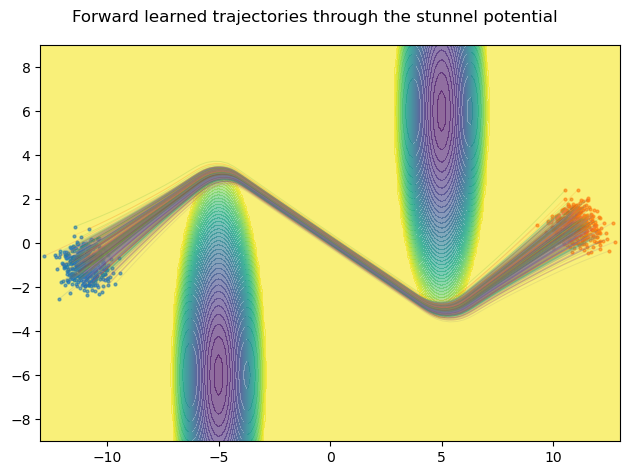


=== Alternating epoch 8 / 20 ===
Solving 64 epoch 7 batch 0 bwd fixed-center three-body BVPs...
epoch 7 batch 0 bwd: kept 61 / 64 BVPs; failed 3; states: torch.Size([61, 51, 6])
epoch 7 batch 0 bwd: first failures: [(26, 'The maximum number of mesh nodes is exceeded.'), (28, 'The maximum number of mesh nodes is exceeded.'), (35, 'The maximum number of mesh nodes is exceeded.')]
epoch 7 batch 0 bwd step     0: loss = 0.28228
epoch 7 batch 0 bwd step   200: loss = 0.42284
epoch 7 batch 0 bwd step   255: loss = 0.51562
Solving 64 epoch 7 batch 1 bwd fixed-center three-body BVPs...
epoch 7 batch 1 bwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 7 batch 1 bwd step     0: loss = 0.24147
epoch 7 batch 1 bwd step   200: loss = 0.47978
epoch 7 batch 1 bwd step   255: loss = 0.21380
Solving 64 epoch 7 batch 2 bwd fixed-center three-body BVPs...
epoch 7 batch 2 bwd: kept 60 / 64 BVPs; failed 4; states: torch.Size([60, 51, 6])
epoch 7 batch 2 bwd: first failures: [(2, 'The

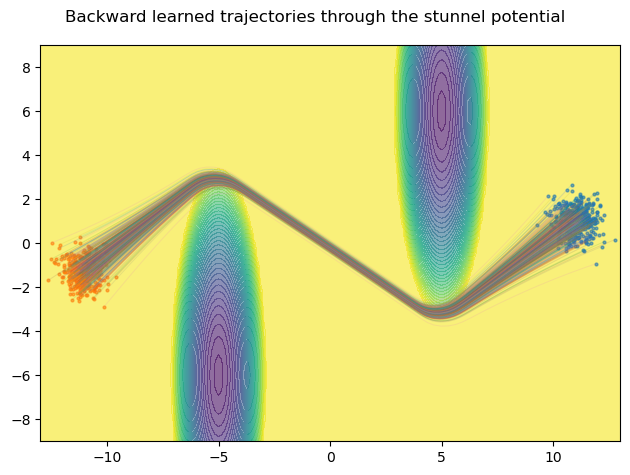


=== Alternating epoch 9 / 20 ===
Solving 64 epoch 8 batch 0 fwd fixed-center three-body BVPs...
epoch 8 batch 0 fwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 8 batch 0 fwd: first failures: [(2, 'The maximum number of mesh nodes is exceeded.')]
epoch 8 batch 0 fwd step     0: loss = 0.34119
epoch 8 batch 0 fwd step   200: loss = 0.23858
epoch 8 batch 0 fwd step   255: loss = 0.11123
Solving 64 epoch 8 batch 1 fwd fixed-center three-body BVPs...
epoch 8 batch 1 fwd: kept 61 / 64 BVPs; failed 3; states: torch.Size([61, 51, 6])
epoch 8 batch 1 fwd: first failures: [(18, 'The maximum number of mesh nodes is exceeded.'), (27, 'The maximum number of mesh nodes is exceeded.'), (53, 'The maximum number of mesh nodes is exceeded.')]
epoch 8 batch 1 fwd step     0: loss = 0.15029
epoch 8 batch 1 fwd step   200: loss = 0.12037
epoch 8 batch 1 fwd step   255: loss = 0.13984
Solving 64 epoch 8 batch 2 fwd fixed-center three-body BVPs...
epoch 8 batch 2 fwd: kept 60 / 64 BV

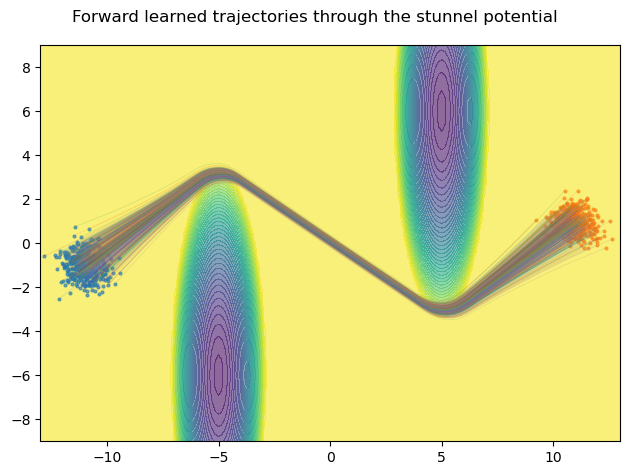


=== Alternating epoch 10 / 20 ===
Solving 64 epoch 9 batch 0 bwd fixed-center three-body BVPs...
epoch 9 batch 0 bwd: kept 60 / 64 BVPs; failed 4; states: torch.Size([60, 51, 6])
epoch 9 batch 0 bwd: first failures: [(1, 'The maximum number of mesh nodes is exceeded.'), (23, 'The maximum number of mesh nodes is exceeded.'), (45, 'The maximum number of mesh nodes is exceeded.'), (59, 'The maximum number of mesh nodes is exceeded.')]
epoch 9 batch 0 bwd step     0: loss = 0.54084
epoch 9 batch 0 bwd step   200: loss = 0.21083
epoch 9 batch 0 bwd step   255: loss = 0.18371
Solving 64 epoch 9 batch 1 bwd fixed-center three-body BVPs...
epoch 9 batch 1 bwd: kept 57 / 64 BVPs; failed 7; states: torch.Size([57, 51, 6])
epoch 9 batch 1 bwd: first failures: [(1, 'The maximum number of mesh nodes is exceeded.'), (2, 'The maximum number of mesh nodes is exceeded.'), (14, 'The maximum number of mesh nodes is exceeded.'), (31, 'The maximum number of mesh nodes is exceeded.'), (36, 'The maximum num

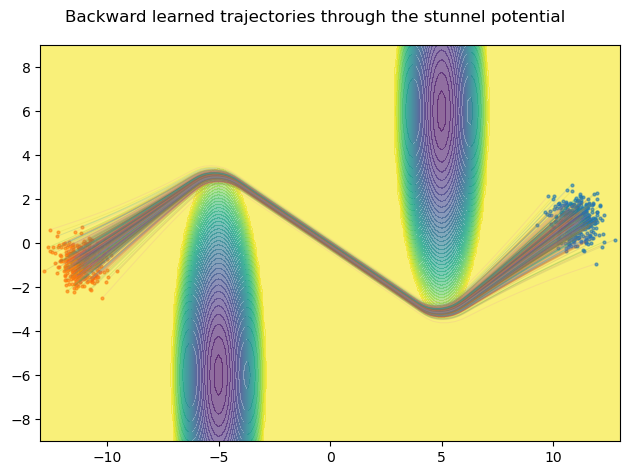


=== Alternating epoch 11 / 20 ===
Solving 64 epoch 10 batch 0 fwd fixed-center three-body BVPs...
epoch 10 batch 0 fwd: kept 60 / 64 BVPs; failed 4; states: torch.Size([60, 51, 6])
epoch 10 batch 0 fwd: first failures: [(39, 'The maximum number of mesh nodes is exceeded.'), (48, 'The maximum number of mesh nodes is exceeded.'), (51, 'The maximum number of mesh nodes is exceeded.'), (53, 'The maximum number of mesh nodes is exceeded.')]
epoch 10 batch 0 fwd step     0: loss = 0.21912
epoch 10 batch 0 fwd step   200: loss = 0.13747
epoch 10 batch 0 fwd step   255: loss = 0.08336
Solving 64 epoch 10 batch 1 fwd fixed-center three-body BVPs...
epoch 10 batch 1 fwd: kept 60 / 64 BVPs; failed 4; states: torch.Size([60, 51, 6])
epoch 10 batch 1 fwd: first failures: [(14, 'The maximum number of mesh nodes is exceeded.'), (16, 'The maximum number of mesh nodes is exceeded.'), (24, 'The maximum number of mesh nodes is exceeded.'), (63, 'The maximum number of mesh nodes is exceeded.')]
epoch 10 

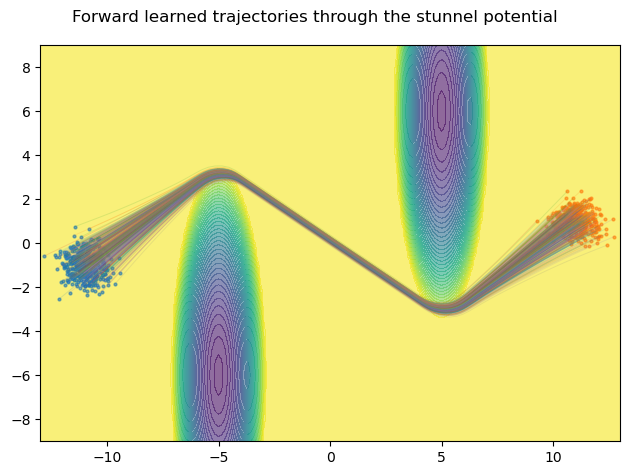


=== Alternating epoch 12 / 20 ===
Solving 64 epoch 11 batch 0 bwd fixed-center three-body BVPs...
epoch 11 batch 0 bwd: kept 59 / 64 BVPs; failed 5; states: torch.Size([59, 51, 6])
epoch 11 batch 0 bwd: first failures: [(3, 'The maximum number of mesh nodes is exceeded.'), (10, 'The maximum number of mesh nodes is exceeded.'), (27, 'The maximum number of mesh nodes is exceeded.'), (29, 'The maximum number of mesh nodes is exceeded.'), (44, 'The maximum number of mesh nodes is exceeded.')]
epoch 11 batch 0 bwd step     0: loss = 0.13241
epoch 11 batch 0 bwd step   200: loss = 0.15347
epoch 11 batch 0 bwd step   255: loss = 0.15833
Solving 64 epoch 11 batch 1 bwd fixed-center three-body BVPs...
epoch 11 batch 1 bwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 11 batch 1 bwd: first failures: [(56, 'The maximum number of mesh nodes is exceeded.')]
epoch 11 batch 1 bwd step     0: loss = 0.26012
epoch 11 batch 1 bwd step   200: loss = 0.16789
epoch 11 batch 1 bwd ste

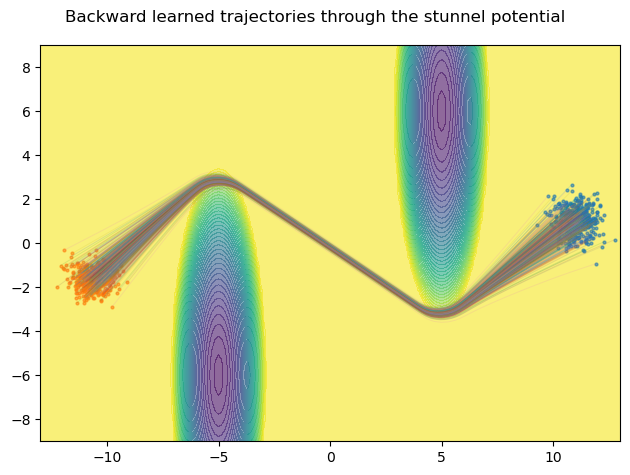


=== Alternating epoch 13 / 20 ===
Solving 64 epoch 12 batch 0 fwd fixed-center three-body BVPs...
epoch 12 batch 0 fwd: kept 58 / 64 BVPs; failed 6; states: torch.Size([58, 51, 6])
epoch 12 batch 0 fwd: first failures: [(7, 'The maximum number of mesh nodes is exceeded.'), (8, 'The maximum number of mesh nodes is exceeded.'), (37, 'The maximum number of mesh nodes is exceeded.'), (43, 'The maximum number of mesh nodes is exceeded.'), (46, 'The maximum number of mesh nodes is exceeded.')]
epoch 12 batch 0 fwd step     0: loss = 0.12263
epoch 12 batch 0 fwd step   200: loss = 0.08096
epoch 12 batch 0 fwd step   255: loss = 0.10447
Solving 64 epoch 12 batch 1 fwd fixed-center three-body BVPs...
epoch 12 batch 1 fwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 12 batch 1 fwd: first failures: [(38, 'The maximum number of mesh nodes is exceeded.')]
epoch 12 batch 1 fwd step     0: loss = 0.08348
epoch 12 batch 1 fwd step   200: loss = 0.17882
epoch 12 batch 1 fwd step

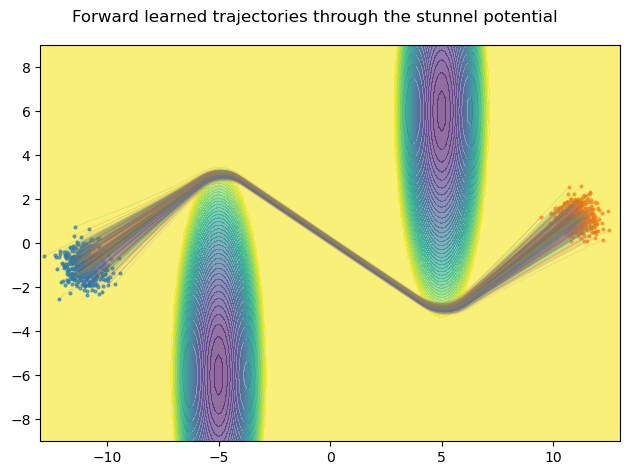


=== Alternating epoch 14 / 20 ===
Solving 64 epoch 13 batch 0 bwd fixed-center three-body BVPs...
epoch 13 batch 0 bwd: kept 60 / 64 BVPs; failed 4; states: torch.Size([60, 51, 6])
epoch 13 batch 0 bwd: first failures: [(15, 'The maximum number of mesh nodes is exceeded.'), (37, 'The maximum number of mesh nodes is exceeded.'), (39, 'The maximum number of mesh nodes is exceeded.'), (53, 'The maximum number of mesh nodes is exceeded.')]
epoch 13 batch 0 bwd step     0: loss = 0.11345
epoch 13 batch 0 bwd step   200: loss = 0.08076
epoch 13 batch 0 bwd step   255: loss = 0.05528
Solving 64 epoch 13 batch 1 bwd fixed-center three-body BVPs...
epoch 13 batch 1 bwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 13 batch 1 bwd: first failures: [(0, 'The maximum number of mesh nodes is exceeded.')]
epoch 13 batch 1 bwd step     0: loss = 0.06173
epoch 13 batch 1 bwd step   200: loss = 0.07268
epoch 13 batch 1 bwd step   255: loss = 0.13861
Solving 64 epoch 13 batch 2 bwd

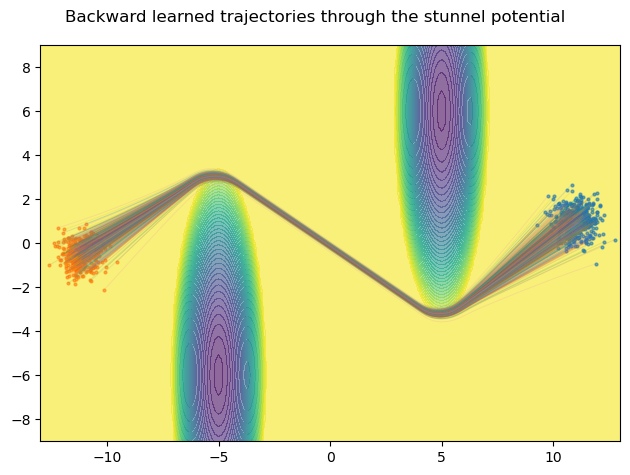


=== Alternating epoch 15 / 20 ===
Solving 64 epoch 14 batch 0 fwd fixed-center three-body BVPs...
epoch 14 batch 0 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 14 batch 0 fwd step     0: loss = 0.19279
epoch 14 batch 0 fwd step   200: loss = 0.08994
epoch 14 batch 0 fwd step   255: loss = 0.06945
Solving 64 epoch 14 batch 1 fwd fixed-center three-body BVPs...
epoch 14 batch 1 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 14 batch 1 fwd step     0: loss = 0.23906
epoch 14 batch 1 fwd step   200: loss = 0.17049
epoch 14 batch 1 fwd step   255: loss = 0.18474
Solving 64 epoch 14 batch 2 fwd fixed-center three-body BVPs...
epoch 14 batch 2 fwd: kept 62 / 64 BVPs; failed 2; states: torch.Size([62, 51, 6])
epoch 14 batch 2 fwd: first failures: [(34, 'The maximum number of mesh nodes is exceeded.'), (56, 'The maximum number of mesh nodes is exceeded.')]
epoch 14 batch 2 fwd step     0: loss = 0.36539
epoch 14 batch 2 fwd step   200: loss =

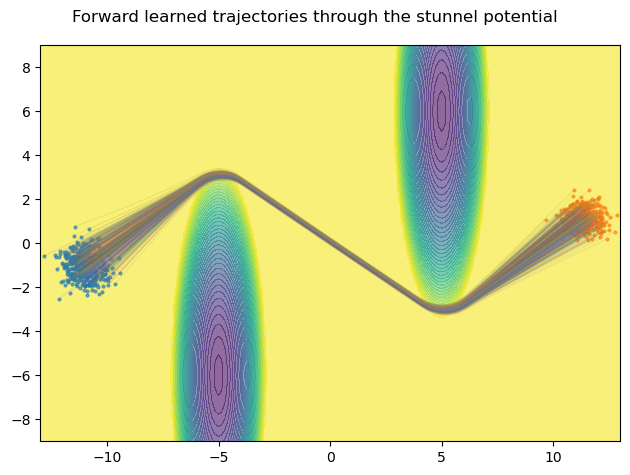


=== Alternating epoch 16 / 20 ===
Solving 64 epoch 15 batch 0 bwd fixed-center three-body BVPs...
epoch 15 batch 0 bwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 15 batch 0 bwd: first failures: [(55, 'The maximum number of mesh nodes is exceeded.')]
epoch 15 batch 0 bwd step     0: loss = 0.12581
epoch 15 batch 0 bwd step   200: loss = 0.06315
epoch 15 batch 0 bwd step   255: loss = 0.14892
Solving 64 epoch 15 batch 1 bwd fixed-center three-body BVPs...
epoch 15 batch 1 bwd: kept 59 / 64 BVPs; failed 5; states: torch.Size([59, 51, 6])
epoch 15 batch 1 bwd: first failures: [(2, 'The maximum number of mesh nodes is exceeded.'), (17, 'The maximum number of mesh nodes is exceeded.'), (20, 'The maximum number of mesh nodes is exceeded.'), (53, 'The maximum number of mesh nodes is exceeded.'), (63, 'The maximum number of mesh nodes is exceeded.')]
epoch 15 batch 1 bwd step     0: loss = 0.10525
epoch 15 batch 1 bwd step   200: loss = 0.13084
epoch 15 batch 1 bwd ste

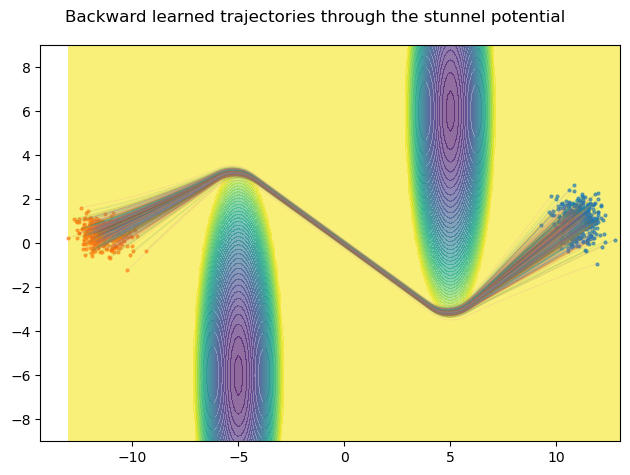


=== Alternating epoch 17 / 20 ===
Solving 64 epoch 16 batch 0 fwd fixed-center three-body BVPs...
epoch 16 batch 0 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 16 batch 0 fwd step     0: loss = 0.11037
epoch 16 batch 0 fwd step   200: loss = 0.13482
epoch 16 batch 0 fwd step   255: loss = 0.13812
Solving 64 epoch 16 batch 1 fwd fixed-center three-body BVPs...
epoch 16 batch 1 fwd: kept 62 / 64 BVPs; failed 2; states: torch.Size([62, 51, 6])
epoch 16 batch 1 fwd: first failures: [(8, 'The maximum number of mesh nodes is exceeded.'), (33, 'The maximum number of mesh nodes is exceeded.')]
epoch 16 batch 1 fwd step     0: loss = 0.09273
epoch 16 batch 1 fwd step   200: loss = 0.08529
epoch 16 batch 1 fwd step   255: loss = 0.04817
Solving 64 epoch 16 batch 2 fwd fixed-center three-body BVPs...
epoch 16 batch 2 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 16 batch 2 fwd step     0: loss = 0.07172
epoch 16 batch 2 fwd step   200: loss = 

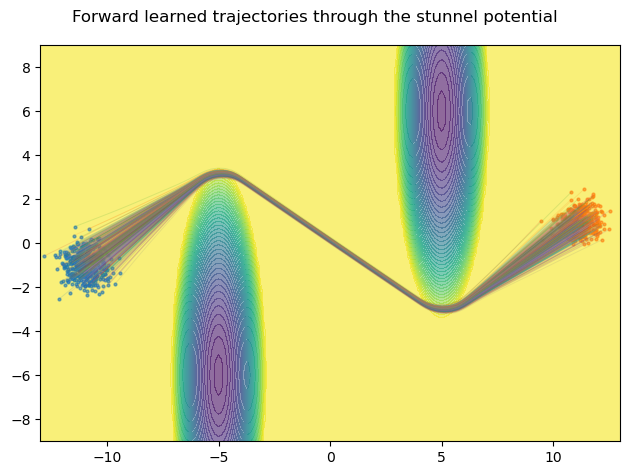


=== Alternating epoch 18 / 20 ===
Solving 64 epoch 17 batch 0 bwd fixed-center three-body BVPs...
epoch 17 batch 0 bwd: kept 62 / 64 BVPs; failed 2; states: torch.Size([62, 51, 6])
epoch 17 batch 0 bwd: first failures: [(15, 'The maximum number of mesh nodes is exceeded.'), (55, 'The maximum number of mesh nodes is exceeded.')]
epoch 17 batch 0 bwd step     0: loss = 0.25609
epoch 17 batch 0 bwd step   200: loss = 0.13263
epoch 17 batch 0 bwd step   255: loss = 0.06744
Solving 64 epoch 17 batch 1 bwd fixed-center three-body BVPs...
epoch 17 batch 1 bwd: kept 61 / 64 BVPs; failed 3; states: torch.Size([61, 51, 6])
epoch 17 batch 1 bwd: first failures: [(23, 'The maximum number of mesh nodes is exceeded.'), (27, 'The maximum number of mesh nodes is exceeded.'), (48, 'The maximum number of mesh nodes is exceeded.')]
epoch 17 batch 1 bwd step     0: loss = 0.04460
epoch 17 batch 1 bwd step   200: loss = 0.05380
epoch 17 batch 1 bwd step   255: loss = 0.07274
Solving 64 epoch 17 batch 2 bw

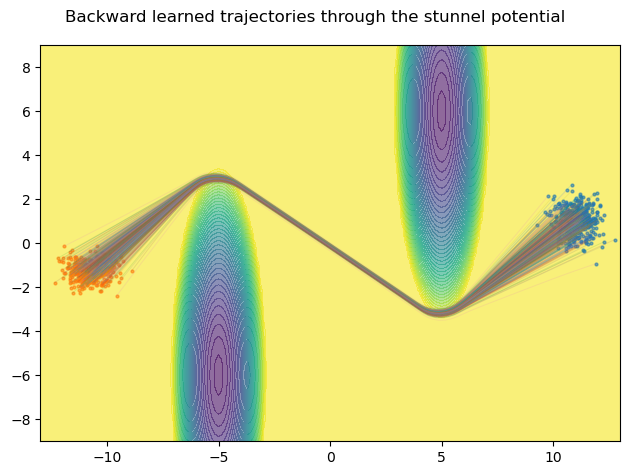


=== Alternating epoch 19 / 20 ===
Solving 64 epoch 18 batch 0 fwd fixed-center three-body BVPs...
epoch 18 batch 0 fwd: kept 64 / 64 BVPs; failed 0; states: torch.Size([64, 51, 6])
epoch 18 batch 0 fwd step     0: loss = 0.14591
epoch 18 batch 0 fwd step   200: loss = 0.12121
epoch 18 batch 0 fwd step   255: loss = 0.07888
Solving 64 epoch 18 batch 1 fwd fixed-center three-body BVPs...
epoch 18 batch 1 fwd: kept 62 / 64 BVPs; failed 2; states: torch.Size([62, 51, 6])
epoch 18 batch 1 fwd: first failures: [(21, 'The maximum number of mesh nodes is exceeded.'), (41, 'The maximum number of mesh nodes is exceeded.')]
epoch 18 batch 1 fwd step     0: loss = 0.07920
epoch 18 batch 1 fwd step   200: loss = 0.04880
epoch 18 batch 1 fwd step   255: loss = 0.03148
Solving 64 epoch 18 batch 2 fwd fixed-center three-body BVPs...
epoch 18 batch 2 fwd: kept 56 / 64 BVPs; failed 8; states: torch.Size([56, 51, 6])
epoch 18 batch 2 fwd: first failures: [(7, 'The maximum number of mesh nodes is exceede

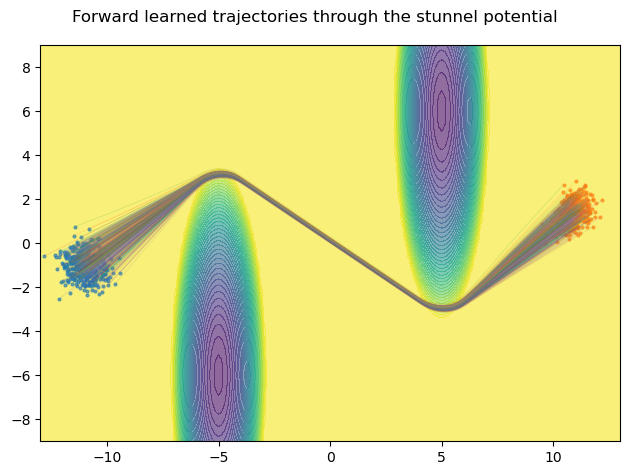


=== Alternating epoch 20 / 20 ===
Solving 64 epoch 19 batch 0 bwd fixed-center three-body BVPs...
epoch 19 batch 0 bwd: kept 60 / 64 BVPs; failed 4; states: torch.Size([60, 51, 6])
epoch 19 batch 0 bwd: first failures: [(22, 'The maximum number of mesh nodes is exceeded.'), (29, 'The maximum number of mesh nodes is exceeded.'), (36, 'The maximum number of mesh nodes is exceeded.'), (42, 'The maximum number of mesh nodes is exceeded.')]
epoch 19 batch 0 bwd step     0: loss = 0.08841
epoch 19 batch 0 bwd step   200: loss = 0.10981
epoch 19 batch 0 bwd step   255: loss = 0.09981
Solving 64 epoch 19 batch 1 bwd fixed-center three-body BVPs...
epoch 19 batch 1 bwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 51, 6])
epoch 19 batch 1 bwd: first failures: [(27, 'The maximum number of mesh nodes is exceeded.')]
epoch 19 batch 1 bwd step     0: loss = 0.18040
epoch 19 batch 1 bwd step   200: loss = 0.07664
epoch 19 batch 1 bwd step   255: loss = 0.07178
Solving 64 epoch 19 batch 2 bw

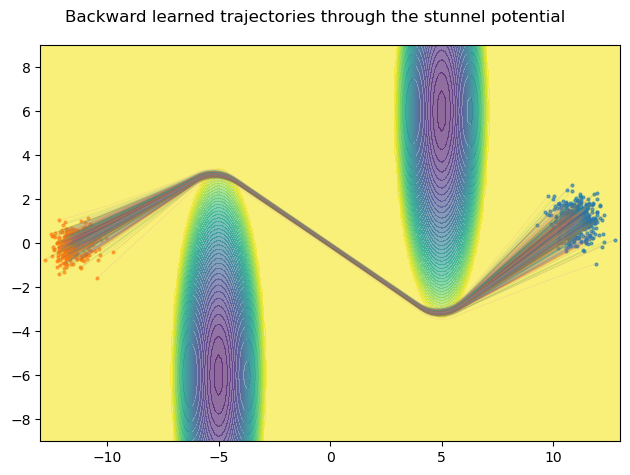

In [8]:
fwd_model = FourierTimeResidualMLP(dim=dim,out_dim=dim,w=256,hidden=4,m=6,time_varying=True).to(device)
bwd_model = FourierTimeResidualMLP(dim=dim,out_dim=dim,w=256,hidden=4,m=6,time_varying=True).to(device)
bwd_optimizer = torch.optim.AdamW(bwd_model.parameters(), lr=5e-5)
fwd_optimizer = torch.optim.AdamW(fwd_model.parameters(), lr=5e-5)
fwd_losses = []
bwd_losses = []

fwd_ema = EMA(
    fwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)

bwd_ema = EMA(
    bwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)

last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None
eval_t_span = torch.linspace(0, 1, 100, device=device)

x0_eval = sample_source(eval_batch//10)
x1_eval = sample_target(eval_batch//10)



def select_generation_model(ema, online_model, ema_name, online_name):
    if ema is not None:
        generation_model = ema.ema_model
        generation_label = ema_name
    else:
        generation_model = online_model
        generation_label = online_name
    generation_model.eval()
    return generation_model, generation_label


class ZeroPotential:
    def energy(self, x):
        return torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)

    def gradient(self, x):
        return torch.zeros_like(x)


zero_potential = ZeroPotential()


def make_linear_path_cache(x0, x1, label):
    path = DeterministicBVPPath(zero_potential, n_steps=n_steps, tol=tol)
    x0_keep = x0.detach()
    x1_keep = x1.detach()
    x0_flat = x0_keep.reshape(x0_keep.shape[0], -1)
    x1_flat = x1_keep.reshape(x1_keep.shape[0], -1)
    t_grid = solve_t_span.to(device=x0_keep.device, dtype=x0_keep.dtype).reshape(1, -1, 1)
    gamma = (1.0 - t_grid) * x0_flat[:, None, :] + t_grid * x1_flat[:, None, :]
    gamma_prime = (x1_flat - x0_flat)[:, None, :].expand(-1, t_grid.shape[1], -1)
    states = torch.cat([gamma, gamma_prime], dim=-1).detach().cpu()
    success_indices = list(range(x0_keep.shape[0]))
    path._record_solve_metadata(x0_keep.shape[0], success_indices, {})
    path._store_cache(x0_keep, x1_keep, states)
    print(
        f"{label}: linear OT zero-potential path; kept {x0_keep.shape[0]} / "
        f"{x0_keep.shape[0]} pairs; states: {states.shape}"
    )
    return {
        'path': path,
        'x0': x0_keep,
        'x1': x1_keep,
        'states': states,
        'label': label,
    }


def generate_fwd_path_cache(epoch, batch_idx, y_target, x_source, generation_model):
    mu_guess, mu_dot_guess = None, None
    if epoch in (0, 1):
        x_source, y_target = ot_sampler.sample_plan(x_source, y_target)
        return make_linear_path_cache(
            x_source,
            y_target,
            label=f"epoch {epoch} batch {batch_idx} fwd",
        )
    else:
        generation_node = make_node(generation_model)
        with torch.no_grad():
            bwd_traj = generation_node.trajectory(y_target, t_span=solve_t_span)
        generated_source = bwd_traj[-1].detach()
        generated_source, x_source, bwd_traj_guess, _ = ot_sampler.sample_plan_with_labels(
            generated_source,
            x_source,
            y0=bwd_traj.permute(1, 0, 2).contiguous(),
            y1=None,
        )
        y_target = bwd_traj_guess[:, 0, :].detach()
        bwd_traj_guess = bwd_traj_guess.permute(1, 0, 2).contiguous()
        mu_guess, mu_dot_guess = trajectory_velocity_guesses(
            generation_model,
            bwd_traj_guess,
            solve_t_span,
            x_source,
            y_target,
            reverse=True,
        )

    path, x0_keep, x1_keep, states = solve_paths(
        x_source,
        y_target,
        label=f'epoch {epoch} batch {batch_idx} fwd',
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
    )
    return {
        'path': path,
        'x0': x0_keep,
        'x1': x1_keep,
        'states': states,
        'label': f'epoch {epoch} batch {batch_idx} fwd',
    }


def generate_bwd_path_cache(epoch, batch_idx, x_source, y_target, generation_model):
    mu_guess, mu_dot_guess = None, None
    if epoch in (0, 1):
        x_source, y_target = ot_sampler.sample_plan(x_source, y_target)
        return make_linear_path_cache(
            y_target,
            x_source,
            label=f"epoch {epoch} batch {batch_idx} bwd",
        )
    else:
        generation_node = make_node(generation_model)
        with torch.no_grad():
            fwd_traj = generation_node.trajectory(x_source, t_span=solve_t_span)
        generated_target = fwd_traj[-1].detach()
        generated_target, y_target, fwd_traj_guess, _ = ot_sampler.sample_plan_with_labels(
            generated_target,
            y_target,
            y0=fwd_traj.permute(1, 0, 2).contiguous(),
            y1=None,
        )
        x_source = fwd_traj_guess[:, 0, :].detach()
        fwd_traj_guess = fwd_traj_guess.permute(1, 0, 2).contiguous()
        mu_guess, mu_dot_guess = trajectory_velocity_guesses(
            generation_model,
            fwd_traj_guess,
            solve_t_span,
            y_target,
            x_source,
            reverse=True,
        )

    path, x0_keep, x1_keep, states = solve_paths(
        y_target,
        x_source,
        label=f'epoch {epoch} batch {batch_idx} bwd',
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
    )
    return {
        'path': path,
        'x0': x0_keep,
        'x1': x1_keep,
        'states': states,
        'label': f'epoch {epoch} batch {batch_idx} bwd',
    }


def train_fwd_on_path_cache(cache):
    return train_on_cached_path_pairs(
        fwd_model,
        fwd_optimizer,
        cache['path'],
        cache['x0'],
        cache['x1'],
        n_iters,
        cache['label'],
        ema=fwd_ema,
        batch_size=batch_size,
        device=device,
        log_every=200,
        no_pairs_message="no successful BVP pairs to train on",
    )


def train_bwd_on_path_cache(cache):
    return train_on_cached_path_pairs(
        bwd_model,
        bwd_optimizer,
        cache['path'],
        cache['x0'],
        cache['x1'],
        n_iters,
        cache['label'],
        ema=bwd_ema,
        batch_size=batch_size,
        device=device,
        log_every=200,
        no_pairs_message="no successful BVP pairs to train on",
    )


for epoch in range(n_epochs):
    print(f'\n=== Alternating epoch {epoch + 1} / {n_epochs} ===')
    train_fwd = (epoch % 2 == 0)
    if epoch in [0,1]:
        source_data = source_dist.sample((warmup_dataset,))
        target_data = target_dist.sample((warmup_dataset,))
    else:
        source_data = source_dist.sample((n_dataset,))
        target_data = target_dist.sample((n_dataset,))
    source_loader = DataLoader(TotalDataset(source_data), batch_size=batch_size, shuffle=True, drop_last=True)
    target_loader = DataLoader(TotalDataset(target_data), batch_size=batch_size, shuffle=True, drop_last=True)

    if train_fwd:
        bwd_generation_model, generation_model = select_generation_model(
            bwd_ema, bwd_model, 'bwd_ema.ema_model', 'bwd_model'
        )
        # print_ema_diagnostic(f'epoch {epoch} fwd cache generation', generation_model=generation_model)
        for i, (y_target, x_source) in enumerate(zip(target_loader, source_loader)):
            fwd_cache = generate_fwd_path_cache(epoch, i, y_target, x_source, bwd_generation_model)
            last_fwd_path = fwd_cache['path']
            last_fwd_x0, last_fwd_x1 = fwd_cache['x0'], fwd_cache['x1']
            last_fwd_states = fwd_cache['states']
            fwd_losses.extend(train_fwd_on_path_cache(fwd_cache))

        with torch.no_grad():
            fwd_model.eval()
            fwd_node = make_node(fwd_model)
            fwd_traj = fwd_node.trajectory(x0_eval, t_span=eval_t_span)
        fwd_traj_plot = to_numpy(fwd_traj)
        fig = plot_trajectories_with_potential(fwd_traj_plot, X, Y, Z, n=eval_batch)
        fig.suptitle('Forward learned trajectories through the stunnel potential')
        plt.tight_layout()
        plt.show()
        if epoch in [0,1]:
            fwd_ema = EMA(
                fwd_model,
                beta=ema_beta,
                update_after_step=ema_update_after_step,
                update_every=ema_update_every,
                min_value=ema_beta,
            ).to(device)
    else:
        fwd_generation_model, generation_model = select_generation_model(
            fwd_ema, fwd_model, 'fwd_ema.ema_model', 'fwd_model'
        )
        # print_ema_diagnostic(f'epoch {epoch} bwd cache generation', generation_model=generation_model)
        for i, (x_source, y_target) in enumerate(zip(source_loader, target_loader)):
            bwd_cache = generate_bwd_path_cache(epoch, i, x_source, y_target, fwd_generation_model)
            last_bwd_path = bwd_cache['path']
            last_bwd_x0, last_bwd_x1 = bwd_cache['x0'], bwd_cache['x1']
            last_bwd_states = bwd_cache['states']
            bwd_losses.extend(train_bwd_on_path_cache(bwd_cache))

        with torch.no_grad():
            bwd_model.eval()
            bwd_node = make_node(bwd_model)
            bwd_traj = bwd_node.trajectory(x1_eval, t_span=eval_t_span)
        bwd_traj_plot= to_numpy(bwd_traj)
        fig = plot_trajectories_with_potential(bwd_traj_plot, X, Y, Z, n=eval_batch)
        fig.suptitle('Backward learned trajectories through the stunnel potential')
        plt.tight_layout()
        plt.show()

        if epoch in [0,1]:
            bwd_ema = EMA(
                bwd_model,
                beta=ema_beta,
                update_after_step=ema_update_after_step,
                update_every=ema_update_every,
                min_value=ema_beta,
                ).to(device)


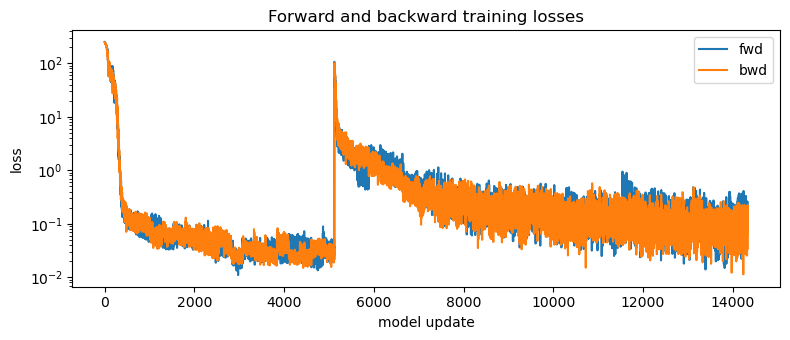

In [9]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(fwd_losses, label='fwd')
plt.semilogy(bwd_losses, label='bwd')
plt.xlabel('model update')
plt.ylabel('loss')
plt.title('Forward and backward training losses')
plt.legend()
plt.tight_layout()
plt.show()


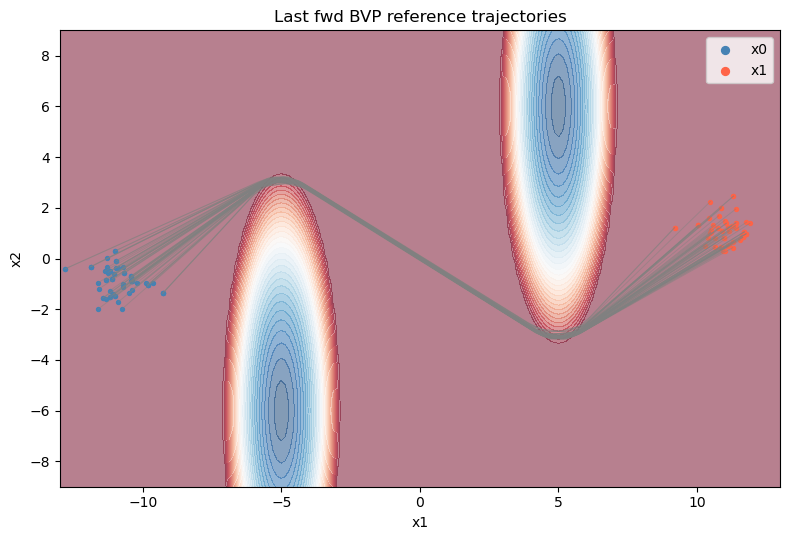

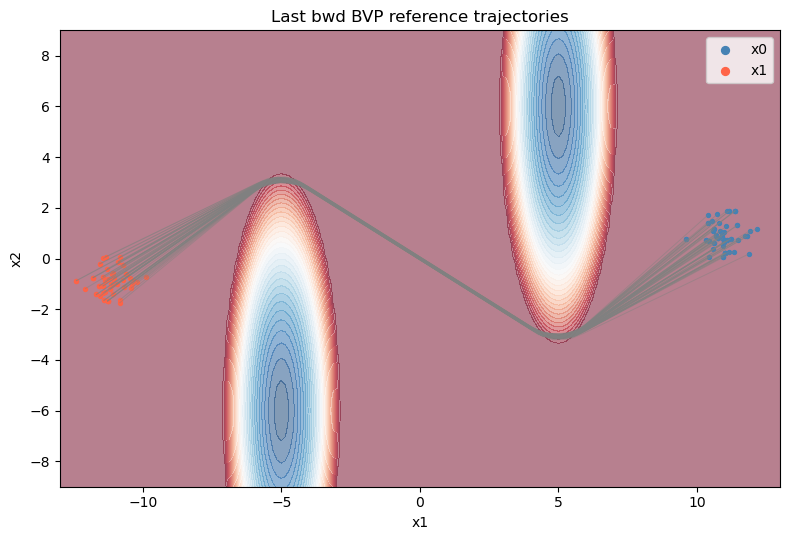

In [10]:
def plot_solved_bvps(states, x0, x1, title, n_show=100):
    n_show = min(n_show, states.shape[0])
    traj_bvp = to_numpy(states[:n_show, :, :dim])
    x0_plot = to_numpy(x0[:n_show])
    x1_plot = to_numpy(x1[:n_show])

    plt.figure(figsize=(8, 5.5))
    plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
    for i in range(n_show):
        plt.plot(traj_bvp[i, :, 0], traj_bvp[i, :, 1], 'gray', alpha=0.45, linewidth=0.7)
    plt.scatter(x0_plot[:, 0], x0_plot[:, 1], s=8, c='steelblue', label='x0')
    plt.scatter(x1_plot[:, 0], x1_plot[:, 1], s=8, c='tomato', label='x1')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(markerscale=2)
    plt.title(title)
    plt.tight_layout()
    plt.show()


if last_fwd_states is not None:
    plot_solved_bvps(last_fwd_states, last_fwd_x0, last_fwd_x1, 'Last fwd BVP reference trajectories')
if last_bwd_states is not None:
    plot_solved_bvps(last_bwd_states, last_bwd_x0, last_bwd_x1, 'Last bwd BVP reference trajectories')


In [11]:


# fwd_ema.ema_model.eval()
# bwd_ema.ema_model.eval()
# fwd_node = make_node(fwd_ema.ema_model)
# bwd_node = make_node(bwd_ema.ema_model)
fwd_model.eval()
bwd_model.eval()
fwd_node = make_node(fwd_model)
bwd_node = make_node(bwd_model)
eval_t_span = torch.linspace(0, 1, n_steps+1, device=device)

with torch.no_grad():
    fwd_traj = fwd_node.trajectory(sample_source(eval_batch), t_span=eval_t_span,)
    bwd_traj = bwd_node.trajectory(sample_target(eval_batch), t_span=eval_t_span)

fwd_traj_plot = to_numpy(fwd_traj)
bwd_traj_plot = to_numpy(bwd_traj)


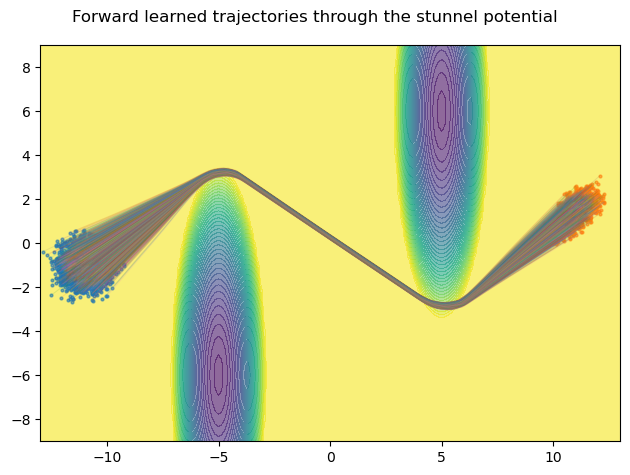

W2 distance:  0.4614186075981019


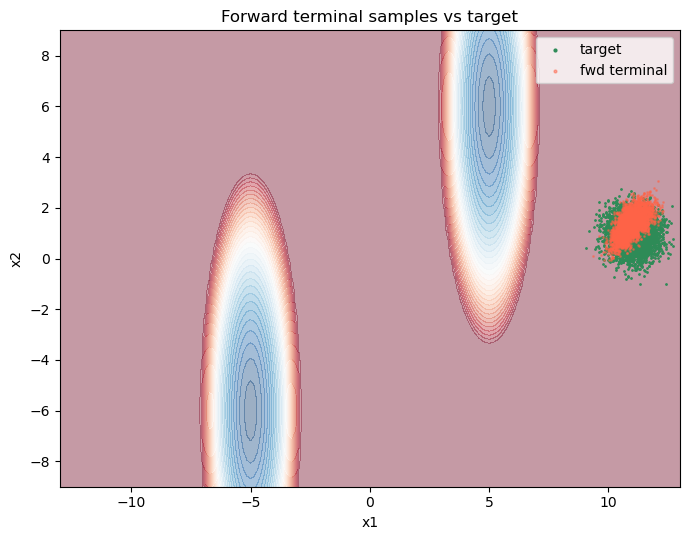

In [12]:
fig = plot_trajectories_with_potential(fwd_traj_plot, X, Y, Z, n=eval_batch)
fig.suptitle('Forward learned trajectories through the stunnel potential')
plt.tight_layout()
plt.show()
x1_ref = sample_target(eval_batch)
print("W2 distance: ", wasserstein(fwd_traj[-1],x1_ref))
x1_ref = to_numpy(x1_ref)
plt.figure(figsize=(7, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.4)
plt.scatter(x1_ref[:, 0], x1_ref[:, 1], s=1, c='seagreen', label='target')
plt.scatter(fwd_traj_plot[-1, :, 0], fwd_traj_plot[-1, :, 1], s=1,alpha=0.5, c='tomato', label='fwd terminal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('Forward terminal samples vs target')
plt.tight_layout()
plt.show()


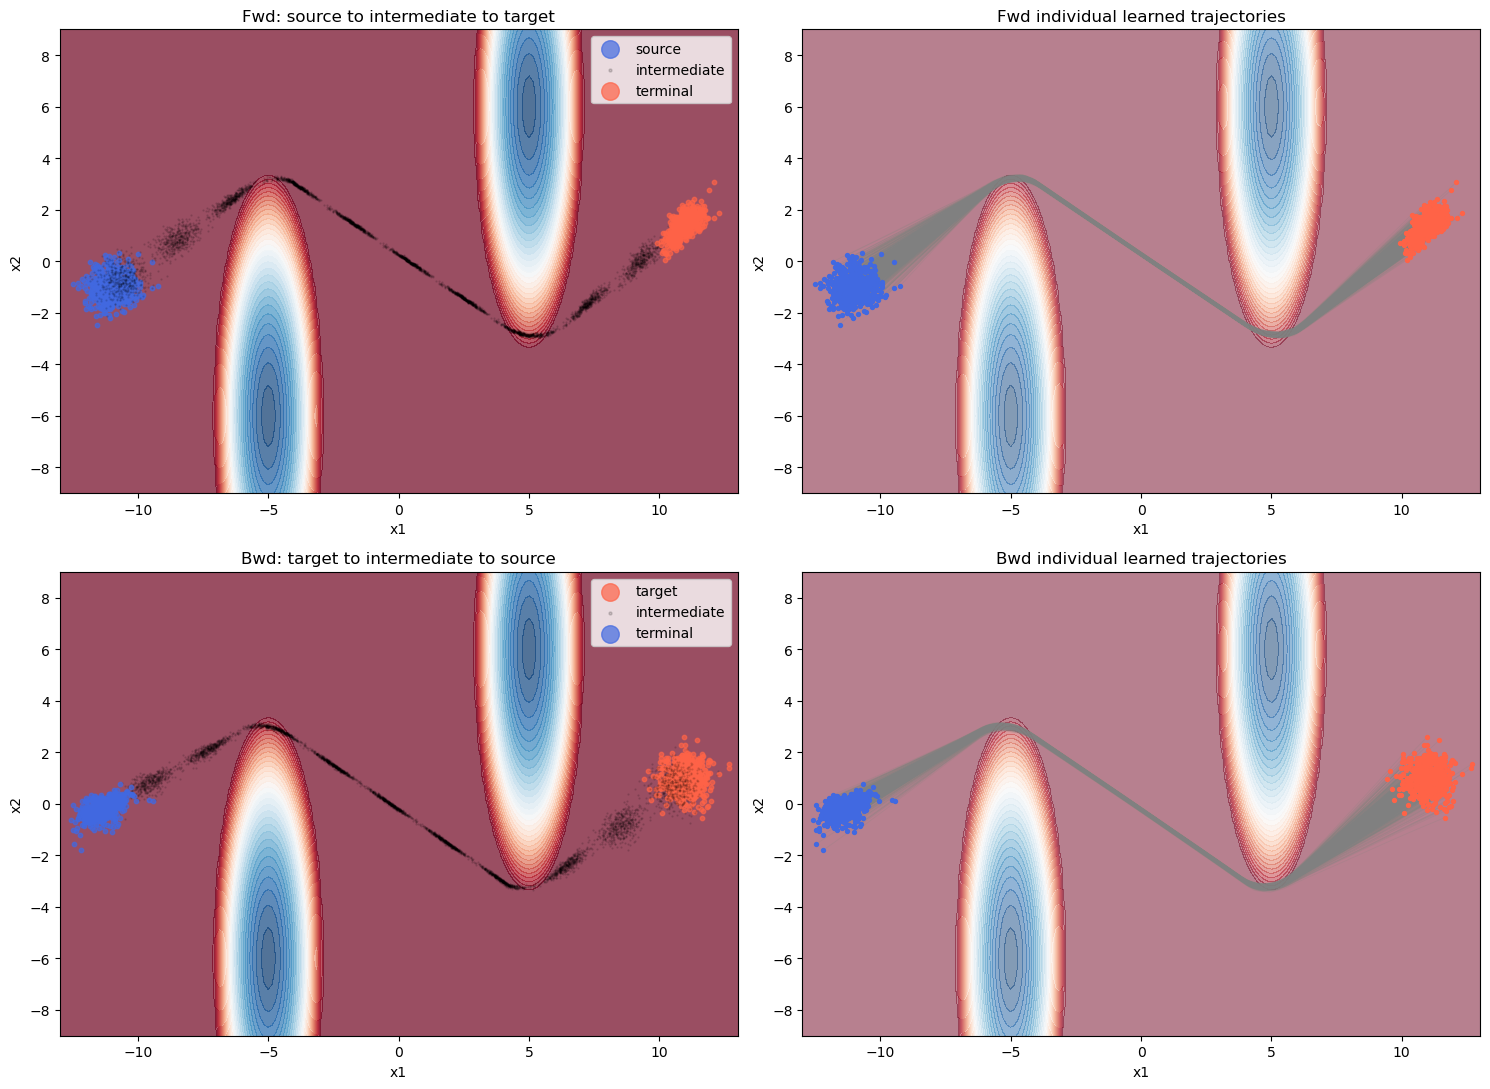

In [13]:
# Source/target, intermediate states, and individual trajectory paths for both directions.
n_show = min(eval_batch, 500)
n_lines = min(eval_batch, 500)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

axes[0, 0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.7)
axes[0, 0].scatter(fwd_traj_plot[0, :n_show, 0], fwd_traj_plot[0, :n_show, 1], s=10, alpha=0.7, c='royalblue', label='source')
axes[0, 0].scatter(fwd_traj_plot[1:-1:5, :n_show, 0].reshape(-1), fwd_traj_plot[1:-1:5, :n_show, 1].reshape(-1), s=0.3, alpha=0.15, c='black', label='intermediate')
axes[0, 0].scatter(fwd_traj_plot[-1, :n_show, 0], fwd_traj_plot[-1, :n_show, 1], s=10, alpha=0.7, c='tomato', label='terminal')
axes[0, 0].set_title('Fwd: source to intermediate to target')
axes[0, 0].legend(markerscale=4)

axes[0, 1].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[0, 1].plot(fwd_traj_plot[:, i, 0], fwd_traj_plot[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
axes[0, 1].scatter(fwd_traj_plot[0, :n_lines, 0], fwd_traj_plot[0, :n_lines, 1], s=8, c='royalblue', zorder=3)
axes[0, 1].scatter(fwd_traj_plot[-1, :n_lines, 0], fwd_traj_plot[-1, :n_lines, 1], s=8, c='tomato', zorder=3)
axes[0, 1].set_title('Fwd individual learned trajectories')

axes[1, 0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.7)
axes[1, 0].scatter(bwd_traj_plot[0, :n_show, 0], bwd_traj_plot[0, :n_show, 1], s=10, alpha=0.7, c='tomato', label='target')
axes[1, 0].scatter(bwd_traj_plot[1:-1:5, :n_show, 0].reshape(-1), bwd_traj_plot[1:-1:5, :n_show, 1].reshape(-1), s=0.3, alpha=0.15, c='black', label='intermediate')
axes[1, 0].scatter(bwd_traj_plot[-1, :n_show, 0], bwd_traj_plot[-1, :n_show, 1], s=10, alpha=0.7, c='royalblue', label='terminal')
axes[1, 0].set_title('Bwd: target to intermediate to source')
axes[1, 0].legend(markerscale=4)

axes[1, 1].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[1, 1].plot(bwd_traj_plot[:, i, 0], bwd_traj_plot[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
axes[1, 1].scatter(bwd_traj_plot[0, :n_lines, 0], bwd_traj_plot[0, :n_lines, 1], s=8, c='tomato', zorder=3)
axes[1, 1].scatter(bwd_traj_plot[-1, :n_lines, 0], bwd_traj_plot[-1, :n_lines, 1], s=8, c='royalblue', zorder=3)
axes[1, 1].set_title('Bwd individual learned trajectories')

for ax in axes.ravel():
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim(-13, 13)
    ax.set_ylim(-9, 9)

plt.tight_layout()
plt.show()
